In [35]:
from pathlib import Path

DATA_DIR = Path("/Users/koensauren/Documents/luisterschelp/model_trainer/processed")
image_paths = sorted(DATA_DIR.glob("*.png"))
labels = [ord(image_path.name[0].lower()) - ord("a") for image_path in image_paths]

print(labels)

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,

In [36]:
from pathlib import Path

from matplotlib import pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np

DATA_DIR = Path("/Users/koensauren/Documents/luisterschelp/model_trainer/processed").with_suffix('')
image_count = len(list(DATA_DIR.glob('*.png')))
print(image_count)

780


Found 780 files belonging to 26 classes.
Using 624 files for training.
Using 156 files for validation.
tf.Tensor(
[[[255.]
  [255.]
  [255.]
  ...
  [255.]
  [255.]
  [255.]]

 [[255.]
  [255.]
  [255.]
  ...
  [255.]
  [255.]
  [255.]]

 [[255.]
  [255.]
  [255.]
  ...
  [255.]
  [255.]
  [255.]]

 ...

 [[255.]
  [255.]
  [255.]
  ...
  [255.]
  [255.]
  [255.]]

 [[255.]
  [255.]
  [255.]
  ...
  [255.]
  [255.]
  [255.]]

 [[255.]
  [255.]
  [255.]
  ...
  [255.]
  [255.]
  [255.]]], shape=(256, 256, 1), dtype=float32)
tf.Tensor(
[[[255.]
  [255.]
  [255.]
  ...
  [255.]
  [255.]
  [255.]]

 [[255.]
  [255.]
  [255.]
  ...
  [255.]
  [255.]
  [255.]]

 [[255.]
  [255.]
  [255.]
  ...
  [255.]
  [255.]
  [255.]]

 ...

 [[255.]
  [255.]
  [255.]
  ...
  [255.]
  [255.]
  [255.]]

 [[255.]
  [255.]
  [255.]
  ...
  [255.]
  [255.]
  [255.]]

 [[255.]
  [255.]
  [255.]
  ...
  [255.]
  [255.]
  [255.]]], shape=(256, 256, 1), dtype=float32)
tf.Tensor(
[[[255.]
  [255.]
  [255.]
  ...
 

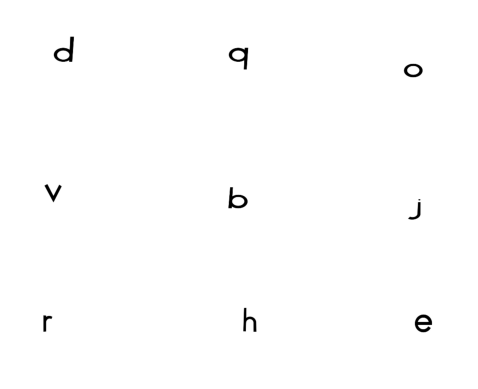

2026-09-12 15:05:44.196899: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [37]:
IMG_SIZE = (256, 256)
BATCH_SIZE = 32
SEED = 42

train_ds, val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    labels=labels,
    validation_split=0.2,
    subset="both",
    seed=SEED,
    image_size=IMG_SIZE,
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
)

# val_ds = tf.keras.utils.image_dataset_from_directory(
#     DATA_DIR,
#     labels=labels,
#     validation_split=0.2,
#     subset="validation",
#     seed=SEED,
#     image_size=IMG_SIZE,
#     color_mode="grayscale",
#     batch_size=BATCH_SIZE,
# )

class_names = train_ds.class_names
num_classes = len(class_names)

image_batch, label_batch = next(iter(train_ds))

import matplotlib.pyplot as plt

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        
        # 1. Grab the image tensor and drop the trailing channel dimension
        # This changes the shape from (30, 30, 1) to (30, 30)
        print(images[i])
        img = np.squeeze(images[i].numpy())
        
        # 2. Force Matplotlib to render it as grayscale using cmap='gray'
        # Also cast to uint8 to keep values correctly ranged 0-255
        plt.imshow(img, cmap="gray")
        
        plt.axis("off")
    plt.show()


Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 212ms/step - accuracy: 0.0369 - loss: 8.6319 - val_accuracy: 0.0128 - val_loss: 3.2924 - learning_rate: 0.0010
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 189ms/step - accuracy: 0.0465 - loss: 4.2730 - val_accuracy: 0.0385 - val_loss: 3.2695 - learning_rate: 0.0010
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 189ms/step - accuracy: 0.0801 - loss: 3.5960 - val_accuracy: 0.0449 - val_loss: 3.2610 - learning_rate: 0.0010
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 188ms/step - accuracy: 0.0962 - loss: 3.2792 - val_accuracy: 0.0449 - val_loss: 3.2720 - learning_rate: 0.0010
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 188ms/step - accuracy: 0.1234 - loss: 3.1185 - val_accuracy: 0.0449 - val_loss: 3.2810 - learning_rate: 0.0010
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 188ms/step - accuracy: 0.1490 - loss: 3.1299 - val_accuracy: 0.0449 - val_loss: 3.2800 - learning_rate: 0.0010
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 188ms/step - accuracy: 0.1907 - loss: 2.

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_10 (Sequential)      │ (None, 256, 256, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_5 (Rescaling)         │ (None, 256, 256, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 256, 256, 32)   │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 256, 256, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 256, 256, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 128, 128, 64)   │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 64, 64, 128)    │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling2d_4          │ (None, 128)            │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 26)             │         3,354 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 555,120 (2.12 MB)

 Trainable params: 184,890 (722.23 KB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 369,782 (1.41 MB)

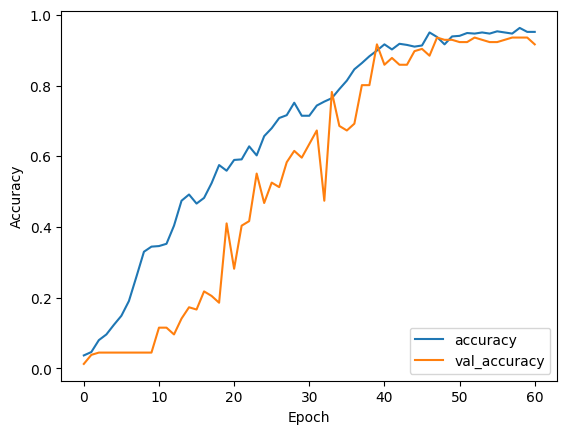

In [52]:
data_augmentation = keras.Sequential([
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.1),
    #layers.RandomTranslation(0.1, 0.1)
])

model = keras.Sequential([
    layers.Input(shape=(*IMG_SIZE, 1)),
    data_augmentation,
    layers.Rescaling(1.0 / 255),

    layers.Conv2D(32, 4, padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 4, padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 4, padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),

    layers.GlobalMaxPooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dense(num_classes, activation="softmax"),
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=8,
        restore_best_weights=True,
        start_from_epoch=50
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
    ),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    callbacks=callbacks
)

print("Classes:", class_names)
model.summary()

plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

[[1.61311298e-03 2.72143463e-08 2.55712960e-02 4.48692408e-05
  2.34373676e-09 7.24337465e-11 1.76446151e-03 1.71816680e-07
  1.60832498e-14 9.90139792e-09 1.02657806e-16 1.37154404e-18
  3.59153705e-06 5.96579710e-08 1.95320207e-03 1.11699349e-03
  9.67930555e-01 1.05778462e-08 1.50362141e-08 5.45953582e-13
  5.47193901e-10 8.43098855e-11 5.30080424e-10 1.09380291e-11
  1.62637787e-06 3.43075980e-12]]


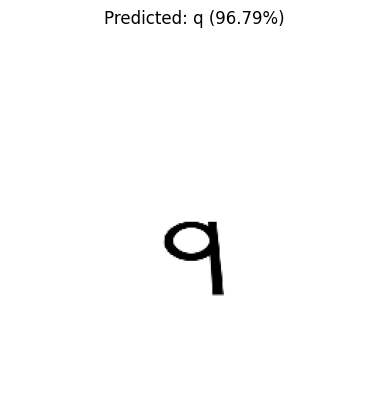

File: q_3d_top.png
Predicted class: q
Confidence: 96.79%


In [110]:
import random

image_path = random.choice(list(DATA_DIR.glob("*.png")))

image = tf.keras.utils.load_img(
    image_path,
    color_mode="grayscale",
    target_size=IMG_SIZE,
)
image_array = tf.keras.utils.img_to_array(image)
image_batch = tf.expand_dims(image_array, axis=0)

predictions = model.predict(image_batch, verbose=0)
print(predictions)
predicted_index = int(np.argmax(predictions[0]))
alphabet = ["a","b","c","d","e","f","g","h","i","j","k","l","m","n","o","p","q","r","s","t","u","v","w","x","y","z"]

predicted_class = alphabet[predicted_index]
confidence = float(predictions[0][predicted_index])

plt.imshow(np.squeeze(image_array), cmap="gray")
plt.axis("off")
plt.title(f"Predicted: {predicted_class} ({confidence:.2%})")
plt.show()

print(f"File: {image_path.name}")
print(f"Predicted class: {predicted_class}")
print(f"Confidence: {confidence:.2%}")

In [111]:
model.save('luisterschelp.keras')

In [2]:
import tensorflow as tf
from pathlib import Path

tf.keras.backend.clear_session()

trained_model = tf.keras.models.load_model(
    "luisterschelp.keras",
    compile=False,
)

# Identify the nested augmentation Sequential layer.
augmentation_layer = next(
    layer
    for layer in trained_model.layers
    if isinstance(layer, tf.keras.Sequential)
    and any(
        layer_name.startswith(("random_rotation", "random_zoom"))
        for layer_name in [child.name for child in layer.layers]
    )
)

# Reuse the trained layers, excluding augmentation.
inference_layers = [
    layer for layer in trained_model.layers
    if layer is not augmentation_layer
]

inference_model = tf.keras.Sequential(
    [
        tf.keras.Input(shape=(256, 256, 1)),
        *inference_layers,
    ]
)

saved_model_dir = Path("luisterschelp_saved_model")
inference_model.export(saved_model_dir)

converter = tf.lite.TFLiteConverter.from_saved_model(
    str(saved_model_dir)
)
tflite_model = converter.convert()

with tf.io.gfile.GFile("model.tflite", "wb") as file:
    file.write(tflite_model)

print("Created model.tflite")

INFO:tensorflow:Assets written to: luisterschelp_saved_model/assets


INFO:tensorflow:Assets written to: luisterschelp_saved_model/assets


Saved artifact at 'luisterschelp_saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 256, 256, 1), dtype=tf.float32, name='keras_tensor_139')
Output Type:
  TensorSpec(shape=(None, 26), dtype=tf.float32, name=None)
Captures:
  5711622416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5711621536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  4446855488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5708560192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5708557376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5717381488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5717392048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5717393104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5719427024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5719426144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5717388176: TensorSpec(shape=(), dtype=tf.resource

W0000 00:00:1789219672.753372 5951894 tf_tfl_flatbuffer_helpers.cc:390] Ignored output_format.
W0000 00:00:1789219672.753381 5951894 tf_tfl_flatbuffer_helpers.cc:393] Ignored drop_control_dependency.
2026-09-12 15:27:52.753491: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: luisterschelp_saved_model
2026-09-12 15:27:52.753855: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-09-12 15:27:52.753858: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: luisterschelp_saved_model
2026-09-12 15:27:52.759505: I tensorflow/cc/saved_model/loader.cc:234] Restoring SavedModel bundle.
2026-09-12 15:27:52.781108: I tensorflow/cc/saved_model/loader.cc:218] Running initialization op on SavedModel bundle at path: luisterschelp_saved_model
2026-09-12 15:27:52.787083: I tensorflow/cc/saved_model/loader.cc:317] SavedModel load for tags { serve }; Status: success: OK. Took 33592 microseconds.
